# ----- ***Data*** -----

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# max row and column
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

TEST_SIZE = 0.2

In [2]:
try:
    import gdown
except ImportError:
    !pip install -q gdown
    import gdown

import os

if os.path.exists('data.csv'):
    print('data.csv already exists')
else:
    url = "https://drive.google.com/uc?id=1efDwAxiFv7cIAlXiQk1Cpjx-ZPzVzAjr"
    gdown.download(url, "data.csv")

data.csv already exists


In [3]:
data = pd.read_csv('data.csv')

In [4]:
data

,x,y,minute,shot_aerial_won,shot_foot,shot_first_time,shot_one_on_one,shot_open_goal,under_pressure,play_pattern_From Corner,play_pattern_From Counter,play_pattern_From Free Kick,play_pattern_From Goal Kick,play_pattern_From Keeper,play_pattern_From Kick Off,play_pattern_From Throw In,play_pattern_Other,play_pattern_Regular Play,technique_Backheel,technique_Diving Header,technique_Half Volley,technique_Lob,technique_Normal,technique_Overhead Kick,technique_Volley,angle,distance,num_opponents_around,num_blocking_players,goal,shot_statsbomb_xg
0,100.4,35.1,6,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,21.792845,19.620652,0,5,0,0.056644
1,114.6,33.5,7,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,37.941499,5.950630,0,1,0,0.143381
2,106.2,55.8,11,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,14.591831,18.157092,0,3,0,0.038188
3,113.9,47.4,13,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,32.715019,6.983552,0,1,0,0.052781
4,89.2,42.5,16,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,14.704957,30.800000,0,4,0,0.021272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14402,95.5,31.6,78,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,16.663676,24.891967,0,2,0,0.030229
14403,99.4,48.8,80,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,18.738696,21.151832,0,3,0,0.043607
14404,94.9,40.8,81,0,1,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,18.091697,25.100000,0,5,0,0.025420
14405,104.5,32.4,88,0,1,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,23.735127,15.912574,0,2,0,0.058556


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = data.corr(numeric_only=True)

corr = corr.style.format("{:.2}")

corr

,x,y,minute,shot_aerial_won,shot_foot,shot_first_time,shot_one_on_one,shot_open_goal,under_pressure,play_pattern_From Corner,play_pattern_From Counter,play_pattern_From Free Kick,play_pattern_From Goal Kick,play_pattern_From Keeper,play_pattern_From Kick Off,play_pattern_From Throw In,play_pattern_Other,play_pattern_Regular Play,technique_Backheel,technique_Diving Header,technique_Half Volley,technique_Lob,technique_Normal,technique_Overhead Kick,technique_Volley,angle,distance,num_opponents_around,num_blocking_players,goal,shot_statsbomb_xg
x,1.0,-0.011,0.018,0.24,-0.35,0.11,0.21,0.15,0.14,0.13,0.029,0.0082,-0.022,-0.0084,-0.026,-0.045,0.029,-0.071,0.058,0.055,0.017,-0.065,-0.057,0.045,0.061,0.55,-0.97,0.24,-0.31,0.2,0.46
y,-0.011,1.0,0.013,0.0061,-0.017,0.035,0.0011,0.0047,0.0035,0.014,0.0014,-0.00045,-0.0047,0.002,0.0076,-0.0036,0.0011,-0.0087,0.013,0.0046,0.028,0.013,-0.041,0.0061,0.019,0.015,0.0092,0.012,0.0015,0.0019,0.01
minute,0.018,0.013,1.0,0.012,0.0022,-0.022,0.00042,0.0055,-0.0071,-0.003,0.025,0.019,0.00095,0.014,-0.036,-0.011,0.0096,-0.011,0.0091,-0.011,-0.01,0.0024,0.023,0.0034,-0.026,0.02,-0.024,0.00019,0.02,0.015,0.031
shot_aerial_won,0.24,0.0061,0.012,1.0,-0.67,-0.2,-0.031,-0.015,0.57,0.27,-0.061,0.035,-0.041,-0.029,-0.016,-0.048,-0.0075,-0.14,-0.016,0.014,-0.11,-0.035,0.14,-0.023,-0.076,0.32,-0.28,0.61,0.029,-0.04,-0.022
shot_foot,-0.35,-0.017,0.0022,-0.67,1.0,0.3,-0.052,-0.0016,-0.32,-0.33,0.085,-0.045,0.038,0.036,0.011,0.059,-0.0011,0.17,0.024,-0.16,0.16,0.044,-0.19,0.034,0.11,-0.46,0.41,-0.44,0.035,0.011,-0.044
shot_first_time,0.11,0.035,-0.022,-0.2,0.3,1.0,-0.17,0.082,-0.15,-0.027,-0.028,0.019,0.0013,0.0005,0.019,0.011,0.024,0.0018,0.065,-0.048,0.23,0.017,-0.4,0.073,0.33,0.1,-0.13,-0.13,0.064,0.11,0.21
shot_one_on_one,0.21,0.0011,0.00042,-0.031,-0.052,-0.17,1.0,0.04,-0.0046,-0.056,0.086,-0.0026,0.0029,0.012,0.014,-0.013,0.0078,0.0089,-0.014,0.043,-0.033,0.1,0.023,-0.012,-0.052,0.034,-0.19,-0.0026,-0.22,0.098,0.2
shot_open_goal,0.15,0.0047,0.0055,-0.015,-0.0016,0.082,0.04,1.0,-0.025,0.009,0.028,-0.0089,0.0074,-0.004,-0.0072,-0.021,0.009,0.0035,0.0053,0.02,0.013,-0.013,-0.02,-0.0086,0.018,0.36,-0.17,-0.0065,-0.15,0.23,0.5
under_pressure,0.14,0.0035,-0.0071,0.57,-0.32,-0.15,-0.0046,-0.025,1.0,0.12,-0.012,0.021,-0.0084,-0.01,-0.0079,-0.025,-0.008,-0.076,-0.013,-0.0021,-0.049,-0.027,0.099,-0.018,-0.078,0.15,-0.15,0.4,-0.00029,-0.038,-0.046
play_pattern_From Corner,0.13,0.014,-0.003,0.27,-0.33,-0.027,-0.056,0.009,0.12,1.0,-0.097,-0.19,-0.095,-0.056,-0.051,-0.2,-0.02,-0.34,0.033,0.0083,0.035,-0.039,-0.066,0.026,0.064,0.2,-0.16,0.19,0.25,-0.037,-0.027


In [6]:
corr_with_goal = data.corr(numeric_only=True)['goal'].sort_values(ascending=False)
display(corr_with_goal)

goal                           1.000000
shot_statsbomb_xg              0.437740
angle                          0.297951
shot_open_goal                 0.226882
x                              0.202374
shot_first_time                0.107214
shot_one_on_one                0.098052
technique_Lob                  0.070245
play_pattern_From Counter      0.041545
play_pattern_Other             0.021357
technique_Diving Header        0.015999
minute                         0.014996
play_pattern_Regular Play      0.012725
play_pattern_From Keeper       0.011710
technique_Volley               0.011386
shot_foot                      0.010509
technique_Backheel             0.002917
y                              0.001891
play_pattern_From Free Kick    0.001636
technique_Overhead Kick       -0.000726
play_pattern_From Goal Kick   -0.005792
play_pattern_From Throw In    -0.005907
num_opponents_around          -0.006104
play_pattern_From Kick Off    -0.006595
technique_Half Volley         -0.010601


In [7]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = data.drop(columns=['goal', 'shot_statsbomb_xg'], axis=1)
y = data['goal']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=42)

In [8]:
X_train.head()

,x,y,minute,shot_aerial_won,shot_foot,shot_first_time,shot_one_on_one,shot_open_goal,under_pressure,play_pattern_From Corner,play_pattern_From Counter,play_pattern_From Free Kick,play_pattern_From Goal Kick,play_pattern_From Keeper,play_pattern_From Kick Off,play_pattern_From Throw In,play_pattern_Other,play_pattern_Regular Play,technique_Backheel,technique_Diving Header,technique_Half Volley,technique_Lob,technique_Normal,technique_Overhead Kick,technique_Volley,angle,distance,num_opponents_around,num_blocking_players
12698,109.5,23.2,31,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,12.577462,16.555664,0,2
9448,111.5,29.0,66,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,20.988758,11.011358,1,1
10572,114.6,39.4,53,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,72.621813,5.400000,0,1
2995,103.0,56.0,25,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,14.417870,20.808652,0,2
12792,111.1,36.6,51,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,43.598992,8.900000,0,2


In [9]:
data.columns

Index(['x', 'y', 'minute', 'shot_aerial_won', 'shot_foot', 'shot_first_time',
       'shot_one_on_one', 'shot_open_goal', 'under_pressure',
       'play_pattern_From Corner', 'play_pattern_From Counter',
       'play_pattern_From Free Kick', 'play_pattern_From Goal Kick',
       'play_pattern_From Keeper', 'play_pattern_From Kick Off',
       'play_pattern_From Throw In', 'play_pattern_Other',
       'play_pattern_Regular Play', 'technique_Backheel',
       'technique_Diving Header', 'technique_Half Volley', 'technique_Lob',
       'technique_Normal', 'technique_Overhead Kick', 'technique_Volley',
       'angle', 'distance', 'num_opponents_around', 'num_blocking_players',
       'goal', 'shot_statsbomb_xg'],
      dtype='object')

# ----- ***Metrics*** -----

In [10]:
# @title Expected Calibration Error
import numpy as np

def expected_calibration_error(y_true, y_prob, n_bins=10):
    """
    Compute Expected Calibration Error (ECE).

    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        Binary ground truth labels (0 or 1).

    y_prob : array-like of shape (n_samples,)
        Predicted probabilities for the positive class.

    n_bins : int, default=10
        Number of equal-width confidence bins.

    Returns
    -------
    ece : float
        Expected Calibration Error.
    """

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    if len(y_true) != len(y_prob):
        raise ValueError("y_true and y_prob must have the same length.")

    if np.any((y_prob < 0) | (y_prob > 1)):
        raise ValueError("Predicted probabilities must be between 0 and 1.")

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    ece = 0.0
    n = len(y_true)

    for i in range(n_bins):
        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        # Include the left endpoint only for the first bin
        if i == 0:
            in_bin = (y_prob >= lower) & (y_prob <= upper)
        else:
            in_bin = (y_prob > lower) & (y_prob <= upper)

        if not np.any(in_bin):
            continue

        accuracy = np.mean(y_true[in_bin])
        confidence = np.mean(y_prob[in_bin])
        weight = np.sum(in_bin) / n

        ece += weight * abs(accuracy - confidence)

    return ece*100

In [11]:
from sklearn.metrics import make_scorer

def custom_combined_score(y_true, y_pred):
    ece = expected_calibration_error(y_true, y_pred)
    return ece

custom_scorer = make_scorer(custom_combined_score, greater_is_better=False, response_method='predict_proba')

In [12]:
# @title Results Dataframe

# create a new df with x_test's indices
results = pd.DataFrame(X_test.index, columns=['index'])
results.set_index('index', inplace=True)
results.index.name = ''

# Add goal probabilities to the test data
results['goal'] = y_test.values
results['statsbomb_xg'] = data.loc[y_test.index, 'shot_statsbomb_xg']

# Display the test data with goal probabilities
results.head()

,goal,statsbomb_xg
,,
11832,1,0.895359
7038,0,0.109529
8613,0,0.026528
3798,0,0.082705
7691,0,0.187825


In [13]:
total_goals_in_test = results['goal'].sum()
print(f'Total goals in the test set: {total_goals_in_test}')

Total goals in the test set: 349


In [14]:
# Add values to the metrics DataFrame

metrics = pd.DataFrame({
    'metric': ['mae', 'Log_Loss', 'brier', 'ece(x100)', f'xg_sum({total_goals_in_test})', 'xg_ratio']
})

metrics = metrics.set_index('metric')
display(metrics.style.format(
    {col: '{:.3f}' for col in metrics.columns}, # Format all columns
))

metric
mae
Log_Loss
brier
ece(x100)
xg_sum(349)
xg_ratio


In [15]:
# @title Evaluate Model (Add To Metrics)

from sklearn.metrics import mean_absolute_error, log_loss, brier_score_loss

def evaluate_model(results, metrics, model_name):
    y_pred = results[model_name]
    goal = results['goal']

    # Calculate metrics
    mae = mean_absolute_error(goal, y_pred)
    Log_Loss = log_loss(goal, y_pred)
    brier = brier_score_loss(goal, y_pred)
    ece = expected_calibration_error(goal, y_pred)
    xg_sum = results[[model_name]].sum()
    xg_ratio = xg_sum / results['goal'].sum()

    # Add to metrics Dataframe
    metrics[model_name] = [mae, Log_Loss, brier, ece, xg_sum.iloc[0], xg_ratio.iloc[0]]

    # Show the metrics Dataframe
    display(metrics.style.format(
        {col: '{:.3f}' for col in metrics.columns}, # Format all columns
    ))

    return metrics

In [16]:
# evaluate statsbomb xg with our new function
metrics = evaluate_model(results, metrics, 'statsbomb_xg')

,statsbomb_xg
metric,
mae,0.165
Log_Loss,0.299
brier,0.087
ece(x100),1.628
xg_sum(349),302.778
xg_ratio,0.868


In [17]:
# Print the number of goals in the training and test sets
print(f"Number of goals in the training set: {y_train.sum()}/{len(y_train)} {(y_train.sum()/len(y_train)):.3}")
print(f"Number of goals in the test set: {y_test.sum()}/{len(y_test)} {(y_test.sum()/len(y_test)):.3}")

Number of goals in the training set: 1331/11525 0.115
Number of goals in the test set: 349/2882 0.121


In [18]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

def show_calibration_curve(results):

    # for all models
    for model_name in results.columns[1:]:
        prob_true, prob_pred = calibration_curve(results['goal'], results[model_name], n_bins=10)
        plt.plot(prob_pred, prob_true, marker='o', label=model_name)
        plt.plot([0,1],[0,1], linestyle='--')
        plt.title(model_name.replace('_', ' ').title())
        plt.xlabel("Predicted probability")
        plt.ylabel("Empirical frequency")

        # Her bindeki şut sayısı
        bins = np.linspace(0, 1, 11)
        binids = np.digitize(results[model_name], bins) - 1
        for i in range(len(prob_pred)):
            count = np.sum(binids == i)
            plt.text(prob_pred[i], prob_true[i] + 0.03, str(count), ha='center', fontsize=9)

        # write ece scores on top left corner for each model
        plt.text(0.05, 0.90, f"EC Error: {expected_calibration_error(results['goal'], results[model_name]):.4f}", transform=plt.gca().transAxes)

        plt.legend()
        plt.show()

# ----- ***Models*** -----

## Logistic Regression

### Scale

In [19]:
# Continuous columns
continuous_cols = ['x', 'y', 'minute', 'angle', 'distance']

In [20]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
minmaxscaler = MinMaxScaler()

# Fit and transform the scaler on the training data to use in logistic
X_train_log = X_train.copy()
X_train_log[continuous_cols] = minmaxscaler.fit_transform(X_train[continuous_cols])

# Only transform
X_test_log = X_test.copy()
X_test_log[continuous_cols] = minmaxscaler.transform(X_test[continuous_cols])

In [21]:
# Discrete columns
discrete_cols = ['num_opponents_around', 'num_blocking_players']

In [22]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
standardscaler = StandardScaler()

# Fit and transform the scaler on the training data to use in logistic
X_train[discrete_cols] = standardscaler.fit_transform(X_train[discrete_cols])

# Only transform
X_test[discrete_cols] = standardscaler.transform(X_test[discrete_cols])



> BU NOKTADA GEREKİRSE FARKLI SCALERLARIN NASIL DEĞİŞİM GÖSTERECEĞİ DENENEBİLİR.

> ANCAK LOGİSTİC MODELİ YALNIZCA BASELİNE OLARAK KULLANACAĞIMIZDAN DOLAYI BU DENEMELERİ GERÇEKLEŞTİRMİYORUZ.

In [23]:
# from sklearn.preprocessing import QuantileTransformer, RobustScaler

# # Create a DataFrame to store the transformed results
# transformed_df = pd.DataFrame(X_train['x'])
# transformed_df.rename(columns={'x':'original_x'}, inplace=True)

# # Standart Scaler
# from sklearn.preprocessing import StandardScaler
# standard_scaler = StandardScaler()
# transformed_x_standard = standard_scaler.fit_transform(X_train[['x']])
# transformed_df['standard_x'] = transformed_x_standard

# # Min Max Scaler
# from sklearn.preprocessing import MinMaxScaler
# min_max_scaler = MinMaxScaler()
# transformed_x_min_max = min_max_scaler.fit_transform(X_train[['x']])
# transformed_df['min_max_x'] = transformed_x_min_max

# # Log transformation
# transformed_df['log_x'] = np.log1p(X_train['x'])


# # Quantile transformation
# quantile_transformer = QuantileTransformer(output_distribution='normal')
# transformed_x_quantile = quantile_transformer.fit_transform(X_train[['x']])
# transformed_df['quantile_x'] = transformed_x_quantile

# # Quantile transformation (outpurt dist. uniform)
# quantile_transformer_uniform = QuantileTransformer(output_distribution='uniform')
# transformed_x_quantile_uniform = quantile_transformer_uniform.fit_transform(X_train[['x']])
# transformed_df['quantile_uniform_x'] = transformed_x_quantile_uniform

# # Robust scaling
# robust_scaler = RobustScaler()
# transformed_x_robust = robust_scaler.fit_transform(X_train[['x']])
# transformed_df['robust_x'] = transformed_x_robust

# # Display the DataFrame with transformed 'x' column
# print(transformed_df.head())

# transformed_df.describe()

### Model

In [24]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the logistic regression model
logistic_model = LogisticRegression(max_iter = 10000)
logistic_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = logistic_model.predict_proba(X_test)[:, 1]  # Probability of goal

In [25]:
print("Gerçekleşen iterasyon sayısı:", logistic_model.n_iter_)

Gerçekleşen iterasyon sayısı: [3735]


In [26]:
results['log_xg'] = y_pred

# Display the test data with goal probabilities

# rounded dataframe.head
results.round(3).head()

,goal,statsbomb_xg,log_xg
,,,
11832,1,0.895,0.893
7038,0,0.110,0.153
8613,0,0.027,0.061
3798,0,0.083,0.059
7691,0,0.188,0.298


In [27]:
metrics = evaluate_model(results, metrics, 'log_xg')

,statsbomb_xg,log_xg
metric,,
mae,0.165,0.174
Log_Loss,0.299,0.304
brier,0.087,0.088
ece(x100),1.628,0.809
xg_sum(349),302.778,334.343
xg_ratio,0.868,0.958


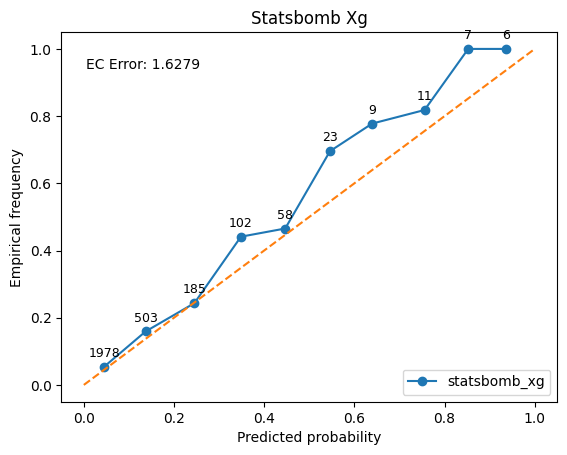

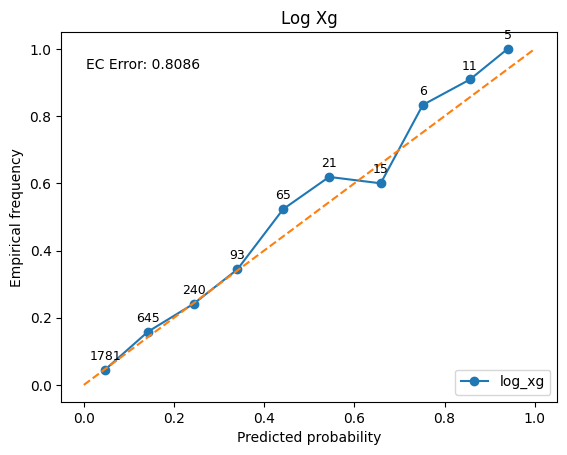

In [28]:
show_calibration_curve(results)

In [29]:
def expected_calibration_error_minmax(y_true, y_prob, bin_min, bin_max, step=0.10):
    bin_edges = np.arange(bin_min, bin_max + step, step)
    bin_indices = np.digitize(y_prob, bin_edges) - 1
    ece = 0.0
    # Adjust bin_edges and bin_indices to handle potential out-of-bounds values from digitize
    # Ensure indices are within the valid range of bin_edges minus 1
    bin_indices = np.clip(bin_indices, 0, len(bin_edges) - 2)

    total_shot_count = 0
    for i in range(len(bin_edges) - 1):
        # Select data points within the current bin
        bin_mask = (y_prob >= bin_edges[i]) & (y_prob < bin_edges[i+1])

        if np.sum(bin_mask) == 0:
            continue
        bin_conf = np.mean(y_prob[bin_mask])
        bin_acc = np.mean(y_true[bin_mask])
        ece += np.abs(bin_acc - bin_conf) * (np.sum(bin_mask) / len(y_true))
        total_shot_count += np.sum(bin_mask)
    return (100 * ece) / total_shot_count

lower_bound = 0.0
upper_bound = 0.4
ece_logistic_minmax = expected_calibration_error_minmax(results['goal'], results['log_xg'], bin_min=lower_bound, bin_max=upper_bound, step=0.1)
print(f"xG ECE ({lower_bound} to {upper_bound}, 0.1 step): {ece_logistic_minmax:.6f}")

lower_bound = 0.4
upper_bound = 0.7
ece_logistic_minmax = expected_calibration_error_minmax(results['goal'], results['log_xg'], bin_min=lower_bound, bin_max=upper_bound, step=0.1)
print(f"xG ECE ({lower_bound} to {upper_bound}, 0.1 step): {ece_logistic_minmax:.6f}")

lower_bound = 0.7
upper_bound = 1
ece_logistic_minmax = expected_calibration_error_minmax(results['goal'], results['log_xg'], bin_min=lower_bound, bin_max=upper_bound, step=0.1)
print(f"xG ECE ({lower_bound} to {upper_bound}, 0.1 step): {ece_logistic_minmax:.6f}")

xG ECE (0.0 to 0.4, 0.1 step): 0.000179
xG ECE (0.4 to 0.7, 0.1 step): 0.002652
xG ECE (0.7 to 1, 0.1 step): 0.002161


In [30]:
def analyze_range(results, from_, to_, xg_column):
    """Belirtilen xG aralığında gol olasılığı ve ortalama xG analizini yapar."""
    filtered = results[(results[xg_column] >= from_) & (results[xg_column] < to_)]
    total_goals = filtered['goal'].sum()
    total_shots = len(filtered)
    probability = total_goals / total_shots if total_shots > 0 else 0
    xg_mean = filtered[xg_column].mean() if total_shots > 0 else np.nan
    return total_goals, total_shots, probability, xg_mean

In [31]:
def analyze_all_models(results, xg_model_columns, step=0.1):
    """Analyzes all xG models over specified bin ranges and returns a formatted DataFrame."""
    analysis_results = []

    for i in range(int(1 / step)):
        from_ = i * step
        to_ = (i + 1) * step
        row = {"Range": f"[{from_:.1f}, {to_:.1f})"}

        for model in xg_model_columns:
            goals, shots, prob, xg_mean = analyze_range(results, from_, to_, model)
            row[f"{model[:-3]}_ratio"] = f"{goals} / {shots}"
            row[f"{model[:-3]}_prob/mean"] = f"{prob:.3f} / {xg_mean:.3f}" if not np.isnan(xg_mean) else "0.000 / nan"

        analysis_results.append(row)

    return pd.DataFrame(analysis_results)

In [32]:
xg_columns = results.columns[1:]
analysis_df = analyze_all_models(results, xg_columns)
analysis_df

,Range,statsbomb_ratio,statsbomb_prob/mean,log_ratio,log_prob/mean
0,"[0.0, 0.1)",107 / 1978,0.054 / 0.045,81 / 1781,0.045 / 0.047
1,"[0.1, 0.2)",80 / 503,0.159 / 0.137,102 / 645,0.158 / 0.142
2,"[0.2, 0.3)",45 / 185,0.243 / 0.245,58 / 240,0.242 / 0.244
3,"[0.3, 0.4)",45 / 102,0.441 / 0.348,32 / 93,0.344 / 0.341
4,"[0.4, 0.5)",27 / 58,0.466 / 0.447,34 / 65,0.523 / 0.442
5,"[0.5, 0.6)",16 / 23,0.696 / 0.546,13 / 21,0.619 / 0.544
6,"[0.6, 0.7)",7 / 9,0.778 / 0.639,9 / 15,0.600 / 0.658
7,"[0.7, 0.8)",9 / 11,0.818 / 0.756,5 / 6,0.833 / 0.752
8,"[0.8, 0.9)",7 / 7,1.000 / 0.852,10 / 11,0.909 / 0.856
9,"[0.9, 1.0)",6 / 6,1.000 / 0.936,5 / 5,1.000 / 0.940


In [33]:
# prompt: xg'si 0.09 olan şutları filtrele

# Filter shots with xG of 0.09
xg_009_shots = results[results['statsbomb_xg'].round(2) == 0.09]

# Display the filtered shots
print(xg_009_shots['goal'].sum()/len(xg_009_shots))

0.1076923076923077


In [34]:
# @title Metrics per bin

# def calculate_metrics(df, from_, to_):
#     """Calculates MAE and Brier score for a given xG range."""
#     filtered_df = df[(df['log_xg'] >= from_) & (df['log_xg'] < to_)]

#     mae_log = mean_absolute_error(filtered_df['goal'], filtered_df['log_xg'])
#     mae_sb = mean_absolute_error(filtered_df['goal'], filtered_df['statsbomb_xg'])

#     brier_log = brier_score_loss(filtered_df['goal'], filtered_df['log_xg'])
#     brier_sb = brier_score_loss(filtered_df['goal'], filtered_df['statsbomb_xg'])

#     return mae_log, mae_sb, brier_log, brier_sb

# # Create an empty list to store the results
# metrics_results = []

# # Iterate through the 0.10 ranges
# for i in range(10):
#     from_ = i / 10
#     to_ = (i + 1) / 10
#     mae_log, mae_sb, brier_log, brier_sb = calculate_metrics(results, from_, to_)
#     metrics_results.append([f"[{from_}, {to_})", mae_log, mae_sb, brier_log, brier_sb])

# # Create a pandas DataFrame from the results
# metrics_per_bin_df = pd.DataFrame(metrics_results, columns=["range", "log_mae", "sb_mae", "log_brier", "sb_brier"])

# # Display the DataFrame
# metrics_per_bin_df


## Random Forest

In [35]:
# Define features (X) and target (y)
X = data.drop(columns=['goal', 'shot_statsbomb_xg'], axis=1)
y = data['goal']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=42)

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict_proba(X_test)[:, 1]
results['rf_xg'] = rf_pred

In [37]:
metrics = evaluate_model(results, metrics, 'rf_xg')

,statsbomb_xg,log_xg,rf_xg
metric,,,
mae,0.165,0.174,0.179
Log_Loss,0.299,0.304,0.382
brier,0.087,0.088,0.092
ece(x100),1.628,0.809,2.702
xg_sum(349),302.778,334.343,351.410
xg_ratio,0.868,0.958,1.007


In [38]:
# # @title Load Best_Rf_Model

# if not os.path.exists('best_rf_model.pkl'):
#     url = "https://drive.google.com/uc?id=1W50Y3rGwFs3ACisE4vXqmoWkRN2zHfGm"  //ÇALIŞMAYI TAMAMEN BİTİRMEDİĞİM İÇİN DRİVE LİNKİNİ GÜNCELLEMEDİM
#     gdown.download(url, "best_rf_model.pkl")


# best_rf_model = joblib.load('best_rf_model.pkl')

# best_rf_pred = best_rf_model.predict_proba(X_test)[:, 1]
# results['best_rf_xg'] = best_rf_pred

In [39]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [40]:
from sklearn.model_selection import GridSearchCV

if not os.path.exists('best_rf_model.pkl'):
    # Define the parameter grid for RandomForestClassifier
    param_grid_rf = {
        'n_estimators': [50, 100, 200],  # Number of trees in the forest
        'max_depth': [None, 10, 20],  # Maximum depth of the trees
        'min_samples_split': [5, 10],  # Minimum number of samples required to split an internal node
        'min_samples_leaf': [1, 2, 4]  # Minimum number of samples required to be at a leaf node
    }

    # Create a GridSearchCV object for RandomForestClassifier
    grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=cv, scoring='neg_log_loss', return_train_score=True, n_jobs=-1)

    # Fit the grid search to the training data
    grid_search_rf.fit(X_train, y_train)

    # Get the best hyperparameters and best score
    print("Best Hyperparameters (Random Forest):", grid_search_rf.best_params_)
    print("Best Score (Random Forest):", grid_search_rf.best_score_)

    # Train the best Random Forest model
    best_rf_model = grid_search_rf.best_estimator_
    best_rf_pred = best_rf_model.predict_proba(X_test)[:, 1]

    # Add best scores of best_rf model
    results['best_rf_xg'] = best_rf_pred

Best Hyperparameters (Random Forest): {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 200}
Best Score (Random Forest): -0.2949584884491352


In [41]:
# #@title Save Best_Rf_Model

# # Save the trained model to a file
# joblib.dump(best_rf_model, 'best_rf_model.pkl')

In [42]:
metrics = evaluate_model(results, metrics, 'best_rf_xg')

,statsbomb_xg,log_xg,rf_xg,best_rf_xg
metric,,,,
mae,0.165,0.174,0.179,0.178
Log_Loss,0.299,0.304,0.382,0.303
brier,0.087,0.088,0.092,0.089
ece(x100),1.628,0.809,2.702,0.895
xg_sum(349),302.778,334.343,351.410,336.752
xg_ratio,0.868,0.958,1.007,0.965


In [43]:
pt = pd.DataFrame(grid_search_rf.cv_results_)

pt.to_excel('grid_search_rf.xlsx')

In [44]:
xg_columns = results.columns[1:]
analysis_df = analyze_all_models(results, xg_columns)
display(analysis_df)

,Range,statsbomb_ratio,statsbomb_prob/mean,log_ratio,log_prob/mean,rf_ratio,rf_prob/mean,best_rf_ratio,best_rf_prob/mean
0,"[0.0, 0.1)",107 / 1978,0.054 / 0.045,81 / 1781,0.045 / 0.047,94 / 1661,0.057 / 0.035,69 / 1614,0.043 / 0.046
1,"[0.1, 0.2)",80 / 503,0.159 / 0.137,102 / 645,0.158 / 0.142,76 / 619,0.123 / 0.139,115 / 808,0.142 / 0.143
2,"[0.2, 0.3)",45 / 185,0.243 / 0.245,58 / 240,0.242 / 0.244,59 / 311,0.190 / 0.241,73 / 297,0.246 / 0.241
3,"[0.3, 0.4)",45 / 102,0.441 / 0.348,32 / 93,0.344 / 0.341,32 / 128,0.250 / 0.344,34 / 78,0.436 / 0.350
4,"[0.4, 0.5)",27 / 58,0.466 / 0.447,34 / 65,0.523 / 0.442,36 / 80,0.450 / 0.438,27 / 44,0.614 / 0.445
5,"[0.5, 0.6)",16 / 23,0.696 / 0.546,13 / 21,0.619 / 0.544,23 / 45,0.511 / 0.541,8 / 16,0.500 / 0.544
6,"[0.6, 0.7)",7 / 9,0.778 / 0.639,9 / 15,0.600 / 0.658,8 / 16,0.500 / 0.657,3 / 3,1.000 / 0.626
7,"[0.7, 0.8)",9 / 11,0.818 / 0.756,5 / 6,0.833 / 0.752,9 / 10,0.900 / 0.758,8 / 10,0.800 / 0.749
8,"[0.8, 0.9)",7 / 7,1.000 / 0.852,10 / 11,0.909 / 0.856,6 / 6,1.000 / 0.860,12 / 12,1.000 / 0.844
9,"[0.9, 1.0)",6 / 6,1.000 / 0.936,5 / 5,1.000 / 0.940,6 / 6,1.000 / 0.923,0 / 0,0.000 / nan


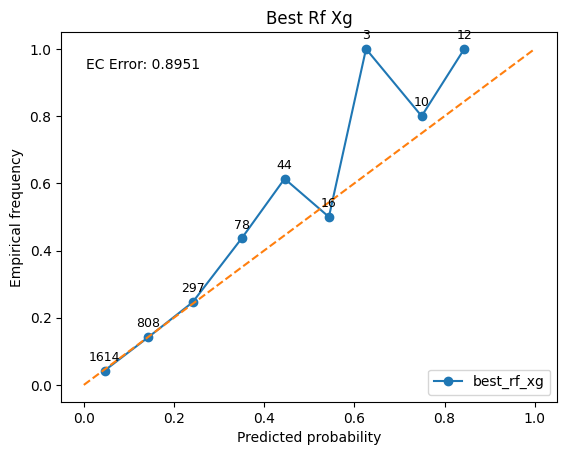

In [45]:
show_calibration_curve(results[['goal', 'best_rf_xg']])

                        Feature  Importance
25                        angle    0.238320
26                     distance    0.157472
0                             x    0.108450
28         num_blocking_players    0.098697
7                shot_open_goal    0.086045
1                             y    0.084550
2                        minute    0.053559
5               shot_first_time    0.026592
4                     shot_foot    0.021592
6               shot_one_on_one    0.015509
21                technique_Lob    0.013175
9      play_pattern_From Corner    0.012719
3               shot_aerial_won    0.012152
22             technique_Normal    0.010056
8                under_pressure    0.009980
27         num_opponents_around    0.008070
11  play_pattern_From Free Kick    0.007517
17    play_pattern_Regular Play    0.006729
15   play_pattern_From Throw In    0.006666
10    play_pattern_From Counter    0.005591
20        technique_Half Volley    0.005499
24             technique_Volley 

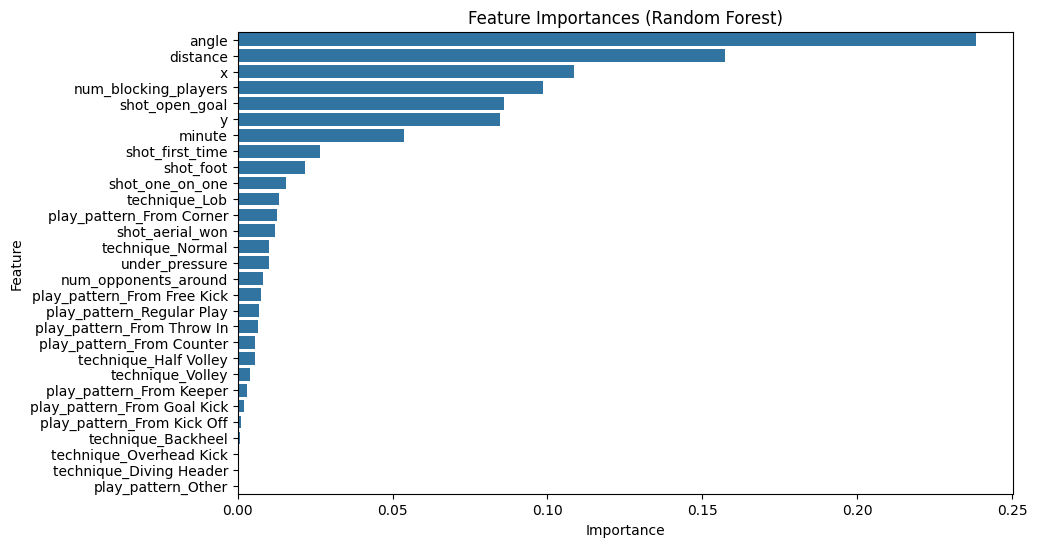

In [46]:
# @title Feature Importance with Random Forest
importances = best_rf_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the feature importances
print(feature_importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances (Random Forest)')
plt.show()

## XGBoost

In [47]:
# XGBoost model
import xgboost as xgb

# Initialize and train the XGBoost model
xgb_model = xgb.XGBClassifier(objective='binary:logistic', random_state=42)  # Use binary:logistic for probability output
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
xgb_pred = xgb_model.predict_proba(X_test)[:, 1]  # Probability of goal

In [48]:
results['xgb_xg'] = xgb_pred

results.round(3).head()

,goal,statsbomb_xg,log_xg,rf_xg,best_rf_xg,xgb_xg
,,,,,,
11832,1,0.895,0.893,0.73,0.770,0.988
7038,0,0.110,0.153,0.12,0.127,0.269
8613,0,0.027,0.061,0.00,0.029,0.032
3798,0,0.083,0.059,0.11,0.078,0.036
7691,0,0.188,0.298,0.23,0.229,0.156


In [49]:
metrics = evaluate_model(results, metrics, 'xgb_xg')

,statsbomb_xg,log_xg,rf_xg,best_rf_xg,xgb_xg
metric,,,,,
mae,0.165,0.174,0.179,0.178,0.166
Log_Loss,0.299,0.304,0.382,0.303,0.336
brier,0.087,0.088,0.092,0.089,0.095
ece(x100),1.628,0.809,2.702,0.895,4.206
xg_sum(349),302.778,334.343,351.410,336.752,317.739
xg_ratio,0.868,0.958,1.007,0.965,0.910


In [50]:
# @title RANDOMIZED SEARCH CV for XGBoost (for a simple insight)

from sklearn.model_selection import RandomizedSearchCV

if not os.path.exists('random_xgb_model.pkl'):
    # Define the parameter grid for XGBoost
    param_grid_xgb = {
        'n_estimators': [50, 100, 200, 500],
        'learning_rate': [0.01, 0.1, 0.2, 0.3],
        'max_depth': [3, 5, 7, 9],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'gamma': [0, 0.1, 0.2],  # Minimum loss reduction required to make a further partition on a leaf node of the tree
        'min_child_weight': [1, 3, 5], # Minimum sum of instance weight (hessian) needed in a child
        'reg_alpha': [0, 0.1, 1.0] # L1 regularization term on weights
    }

    # Initialize the XGBoost classifier
    temp_xgb_model = xgb.XGBClassifier(objective='binary:logistic', random_state=42)

    scoring = {
        'neg_brier_score': 'neg_brier_score',
        'neg_log_loss': 'neg_log_loss',
        'neg_mean_absolute_error': 'neg_mean_absolute_error'
    }

    # Use RandomizedSearchCV for hyperparameter tuning (more efficient for large parameter grids)
    random_search_xgb = RandomizedSearchCV(estimator=temp_xgb_model, param_distributions=param_grid_xgb, n_iter=50, refit='neg_brier_score', scoring=scoring,
                                           cv=cv, verbose=2, random_state=42, n_jobs=-1, return_train_score=True)

    # Fit the randomized search to the training data
    random_search_xgb.fit(X_train, y_train)

    # Get the best hyperparameters and best score
    print("Best Hyperparameters (XGBoost):", random_search_xgb.best_params_)
    print("Best Score (XGBoost):", random_search_xgb.best_score_)

    # Train the best XGBoost model
    random_xgb_model = random_search_xgb.best_estimator_
    random_xgb_pred = random_xgb_model.predict_proba(X_test)[:, 1]


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Hyperparameters (XGBoost): {'subsample': 0.6, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best Score (XGBoost): -0.0846537347235051


In [51]:
# random_xgb results to excel
pt_xgb = pd.DataFrame(random_search_xgb.cv_results_)
pt_xgb.to_excel('random_search_xgb.xlsx')

In [52]:
results['random_xgb_xg'] = random_xgb_pred

results.round(3).head()

,goal,statsbomb_xg,log_xg,rf_xg,best_rf_xg,xgb_xg,random_xgb_xg
,,,,,,,
11832,1,0.895,0.893,0.73,0.770,0.988,0.848
7038,0,0.110,0.153,0.12,0.127,0.269,0.094
8613,0,0.027,0.061,0.00,0.029,0.032,0.031
3798,0,0.083,0.059,0.11,0.078,0.036,0.063
7691,0,0.188,0.298,0.23,0.229,0.156,0.178


In [53]:
metrics = evaluate_model(results, metrics, 'random_xgb_xg')

,statsbomb_xg,log_xg,rf_xg,best_rf_xg,xgb_xg,random_xgb_xg
metric,,,,,,
mae,0.165,0.174,0.179,0.178,0.166,0.173
Log_Loss,0.299,0.304,0.382,0.303,0.336,0.299
brier,0.087,0.088,0.092,0.089,0.095,0.087
ece(x100),1.628,0.809,2.702,0.895,4.206,1.119
xg_sum(349),302.778,334.343,351.410,336.752,317.739,335.595
xg_ratio,0.868,0.958,1.007,0.965,0.910,0.962


In [54]:
try:
    import optuna
except ImportError:
    !pip install optuna
    import optuna

C:\Users\Ahmet Bülent\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [55]:
# @title Hyperparameter Tuning with Optuna for XGBoost

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 0.5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        'objective': 'binary:logistic',
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'logloss',
    }

    # OOF tahminlerini biriktirmek için boş dizi oluşturuyoruz
    # Veri setiniz pandas DataFrame veya Series ise dizin uyumu için numpy array'e dönüştürüyoruz
    oof_predictions = np.zeros(len(X_train))
    fold_brier_scores = []
    fold_logloss_scores = []
    fold_mae_scores = []

    # Manuel CV döngüsü
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        # Pandas ve Numpy dizinleme farkını yönetmek için iloc kontrolü
        if hasattr(X_train, "iloc"):
            X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]
        else:
            X_tr, X_va = X_train[train_idx], X_train[val_idx]
            y_tr, y_va = y_train[train_idx], y_train[val_idx]

        model = xgb.XGBClassifier(**params)

        model.fit(X_tr, y_tr)

        # Olasılık tahminlerini alıp OOF dizisine yerleştiriyoruz
        val_preds = model.predict_proba(X_va)[:, 1]
        oof_predictions[val_idx] = val_preds

        # Her fold'un skorlarını hesaplayıp listeye ekliyoruz
        fold_brier_scores.append(brier_score_loss(y_va, val_preds))
        fold_logloss_scores.append(log_loss(y_va, val_preds))
        fold_mae_scores.append(mean_absolute_error(y_va, val_preds))

    # Tüm katlamalar bittikten sonra metrikleri hesaplıyoruz
    mean_brier = np.mean(fold_brier_scores)
    mean_logloss = np.mean(fold_logloss_scores)
    mean_mae = np.mean(fold_mae_scores)

    # y_train pandas Series ise numpy array'e dönüştürerek ECE fonksiyonuna gönderiyoruz
    y_train_arr = y_train.to_numpy() if hasattr(y_train, "to_numpy") else y_train
    pooled_ece = expected_calibration_error(y_train_arr, oof_predictions, n_bins=10)

    # Skorları takip edebilmek için Optuna geçmişine kaydediyoruz
    trial.set_user_attr("mean_brier", mean_brier)
    trial.set_user_attr("mean_logloss", mean_logloss)
    trial.set_user_attr("mean_mae", mean_mae)
    trial.set_user_attr("pooled_ece", pooled_ece)

    return mean_brier  # Minimize etmek istediğimiz metrik


study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
print("Best Optuna parameters for XGBoost:", best_params)
print("Best CV Loss Score:", study.best_value)

print("Best CV Mean Brier Score of Best Trial:", study.best_trial.user_attrs["mean_brier"])
print("Best CV Mean Log Loss of Best Trial:", study.best_trial.user_attrs["mean_logloss"])
print("Best CV Mean MAE of Best Trial:", study.best_trial.user_attrs["mean_mae"])
print("Best CV Pooled ECE of Best Trial:", study.best_trial.user_attrs["pooled_ece"])


best_xgb_model_optuna = xgb.XGBClassifier(
    **best_params,
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

best_xgb_model_optuna.fit(X_train, y_train)


best_xgb_optuna_pred = best_xgb_model_optuna.predict_proba(X_test)[:, 1]
results['best_xgb_optuna_xg'] = best_xgb_optuna_pred

[I 2026-07-13 21:24:30,643] A new study created in memory with name: no-name-0f3a848b-375c-478f-b5c0-4581a2bb7469
Best trial: 0. Best value: 0.090502:   2%|▏         | 1/50 [00:02<01:46,  2.18s/it]

[I 2026-07-13 21:24:32,822] Trial 0 finished with value: 0.09050201720989362 and parameters: {'n_estimators': 400, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.07799726016810132, 'min_child_weight': 1, 'reg_alpha': 4.330880728874676, 'reg_lambda': 3.005575058716044}. Best is trial 0 with value: 0.09050201720989362.


Best trial: 0. Best value: 0.090502:   4%|▍         | 2/50 [00:04<01:34,  1.98s/it]

[I 2026-07-13 21:24:34,657] Trial 1 finished with value: 0.09346958016957152 and parameters: {'n_estimators': 750, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'gamma': 0.09091248360355031, 'min_child_weight': 2, 'reg_alpha': 1.5212112147976886, 'reg_lambda': 2.6237821581611893}. Best is trial 0 with value: 0.09050201720989362.


Best trial: 2. Best value: 0.0877731:   6%|▌         | 3/50 [00:05<01:28,  1.87s/it]

...

[I 2026-07-13 21:25:50,463] Trial 47 finished with value: 0.08692818220823224 and parameters: {'n_estimators': 350, 'max_depth': 9, 'learning_rate': 0.022767722666473394, 'subsample': 0.682725234897923, 'colsample_bytree': 0.9641818529187207, 'gamma': 0.499446579733708, 'min_child_weight': 2, 'reg_alpha': 0.6277916344047857, 'reg_lambda': 2.6136258207159635}. Best is trial 44 with value: 0.08455061075482476.


Best trial: 44. Best value: 0.0845506:  98%|█████████▊| 49/50 [01:21<00:01,  1.87s/it]

[I 2026-07-13 21:25:52,088] Trial 48 finished with value: 0.0853003669824891 and parameters: {'n_estimators': 350, 'max_depth': 6, 'learning_rate': 0.01910583017456761, 'subsample': 0.7652455920677061, 'colsample_bytree': 0.9970330205782749, 'gamma': 0.4741537955574704, 'min_child_weight': 1, 'reg_alpha': 1.2123714298409312, 'reg_lambda': 1.324062501628152}. Best is trial 44 with value: 0.08455061075482476.


Best trial: 44. Best value: 0.0845506: 100%|██████████| 50/50 [01:24<00:00,  1.68s/it]


[I 2026-07-13 21:25:54,786] Trial 49 finished with value: 0.08680880299000437 and parameters: {'n_estimators': 700, 'max_depth': 5, 'learning_rate': 0.027906527991630778, 'subsample': 0.6514091576794785, 'colsample_bytree': 0.9669450560374386, 'gamma': 0.11544324995943997, 'min_child_weight': 2, 'reg_alpha': 1.6160866305676516, 'reg_lambda': 3.080936063871875}. Best is trial 44 with value: 0.08455061075482476.
Best Optuna parameters for XGBoost: {'n_estimators': 450, 'max_depth': 5, 'learning_rate': 0.011215131741367776, 'subsample': 0.7709175895256496, 'colsample_bytree': 0.966195635901221, 'gamma': 0.4999712461620379, 'min_child_weight': 2, 'reg_alpha': 1.5360635247090764, 'reg_lambda': 2.5971335406027167}
Best CV Loss Score: 0.08455061075482476
Best CV Mean Brier Score of Best Trial: 0.08455061075482476
Best CV Mean Log Loss of Best Trial: 0.291969563214744
Best CV Mean MAE of Best Trial: 0.16955527663230896
Best CV Pooled ECE of Best Trial: 0.7974040783020527


In [56]:
# optuna to xlsx
pt_optuna = pd.DataFrame(study.trials_dataframe())
pt_optuna.to_excel('optuna_xgb_trials.xlsx')

In [57]:
results.round(3).head()

,goal,statsbomb_xg,log_xg,rf_xg,best_rf_xg,xgb_xg,random_xgb_xg,best_xgb_optuna_xg
,,,,,,,,
11832,1,0.895,0.893,0.73,0.770,0.988,0.848,0.836
7038,0,0.110,0.153,0.12,0.127,0.269,0.094,0.087
8613,0,0.027,0.061,0.00,0.029,0.032,0.031,0.029
3798,0,0.083,0.059,0.11,0.078,0.036,0.063,0.068
7691,0,0.188,0.298,0.23,0.229,0.156,0.178,0.176


In [58]:
metrics = evaluate_model(results, metrics, 'best_xgb_optuna_xg')

,statsbomb_xg,log_xg,rf_xg,best_rf_xg,xgb_xg,random_xgb_xg,best_xgb_optuna_xg
metric,,,,,,,
mae,0.165,0.174,0.179,0.178,0.166,0.173,0.174
Log_Loss,0.299,0.304,0.382,0.303,0.336,0.299,0.300
brier,0.087,0.088,0.092,0.089,0.095,0.087,0.087
ece(x100),1.628,0.809,2.702,0.895,4.206,1.119,0.866
xg_sum(349),302.778,334.343,351.410,336.752,317.739,335.595,335.722
xg_ratio,0.868,0.958,1.007,0.965,0.910,0.962,0.962


In [59]:
oof_predictions = np.zeros(len(X_train))
fold_brier_scores = []
fold_logloss_scores = []
fold_ece_scores = []

# Manuel CV döngüsü
for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    # Pandas ve Numpy dizinleme farkını yönetmek için iloc kontrolü
    if hasattr(X_train, "iloc"):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]
    else:
        X_tr, X_va = X_train[train_idx], X_train[val_idx]
        y_tr, y_va = y_train[train_idx], y_train[val_idx]
    
    model = xgb.XGBClassifier(**best_params, objective='binary:logistic', random_state=42, n_jobs=-1, eval_metric='logloss')
    model.fit(X_tr, y_tr, 
              eval_set=[(X_tr, y_tr), (X_va, y_va)],
              verbose=True
            )

    # Olasılık tahminlerini alıp OOF dizisine yerleştiriyoruz
    val_preds = model.predict_proba(X_va)[:, 1]
    oof_predictions[val_idx] = val_preds

    # Bu fold'un Brier skorunu hesaplayıp listeye ekliyoruz
    fold_brier_scores.append(brier_score_loss(y_va, val_preds))
    fold_logloss_scores.append(log_loss(y_va, val_preds))
    fold_ece_scores.append(expected_calibration_error(y_va.to_numpy(), val_preds, n_bins=10))

ece_best_xgb_optuna = expected_calibration_error(y_train.to_numpy(), oof_predictions, n_bins=10)
print("Best XGBoost ECE Score:", ece_best_xgb_optuna)
print("Best XGBoost Mean Brier Score:", np.mean(fold_brier_scores))
print("Best XGBoost Mean Log Loss:", np.mean(fold_logloss_scores))
print("Best XGBoost Mean ECE Score:", np.mean(fold_ece_scores))

print(fold_brier_scores)
print(fold_logloss_scores)
print(fold_ece_scores)

[0]	validation_0-logloss:0.35628	validation_1-logloss:0.35632
[1]	validation_0-logloss:0.35477	validation_1-logloss:0.35508
[2]	validation_0-logloss:0.35329	validation_1-logloss:0.35384
[3]	validation_0-logloss:0.35185	validation_1-logloss:0.35270
[4]	validation_0-logloss:0.35048	validation_1-logloss:0.35157
[5]	validation_0-logloss:0.34909	validation_1-logloss:0.35035
[6]	validation_0-logloss:0.34775	validation_1-logloss:0.34919
[7]	validation_0-logloss:0.34648	validation_1-logloss:0.34812
[8]	validation_0-logloss:0.34523	validation_1-logloss:0.34709


[9]	validation_0-logloss:0.34400	validation_1-logloss:0.34611
[10]	validation_0-logloss:0.34277	validation_1-logloss:0.34513
[11]	validation_0-logloss:0.34159	validation_1-logloss:0.34412
[12]	validation_0-logloss:0.34042	validation_1-logloss:0.34322
[13]	validation_0-logloss:0.33945	validation_1-logloss:0.34245
[14]	validation_0-logloss:0.33840	validation_1-logloss:0.34163
[15]	validation_0-logloss:0.33730	validation_1-logloss:0.34071
[16]	validation_0-logloss:0.33624	validation_1-logloss:0.33983
[17]	validation_0-logloss:0.33527	validation_1-logloss:0.33901
[18]	validation_0-logloss:0.33428	validation_1-logloss:0.33818
[19]	validation_0-logloss:0.33336	validation_1-logloss:0.33746
[20]	validation_0-logloss:0.33240	validation_1-logloss:0.33668
[21]	validation_0-logloss:0.33149	validation_1-logloss:0.33592
[22]	validation_0-logloss:0.33062	validation_1-logloss:0.33519
[23]	validation_0-logloss:0.32979	validation_1-logloss:0.33456
[24]	validation_0-logloss:0.32898	validation_1-logloss:0

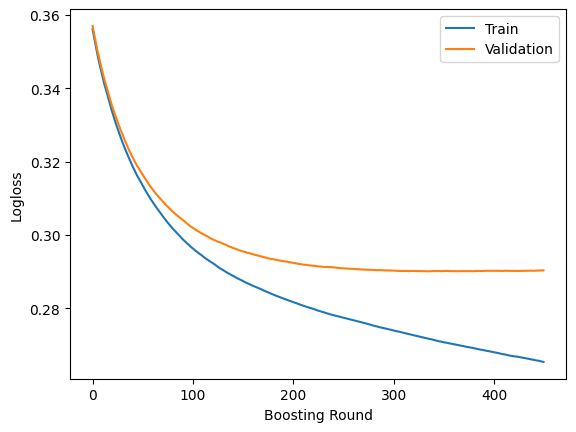

In [60]:
sonuc = model.evals_result()

train_loss = sonuc['validation_0']['logloss']
valid_loss = sonuc['validation_1']['logloss']

plt.plot(train_loss, label='Train')
plt.plot(valid_loss, label='Validation')
plt.xlabel("Boosting Round")
plt.ylabel("Logloss")
plt.legend()
plt.show()

In [61]:
sorted_trials = sorted([t for t in study.trials if t.value is not None], key=lambda t: t.value)
top10_trials = sorted_trials[:10]
top10_params = [trial.params for trial in top10_trials]

top10_params

[{'n_estimators': 450,
  'max_depth': 5,
  'learning_rate': 0.011215131741367776,
  'subsample': 0.7709175895256496,
  'colsample_bytree': 0.966195635901221,
  'gamma': 0.4999712461620379,
  'min_child_weight': 2,
  'reg_alpha': 1.5360635247090764,
  'reg_lambda': 2.5971335406027167},
 {'n_estimators': 550,
  'max_depth': 4,
  'learning_rate': 0.011996425370204906,
  'subsample': 0.752449900226217,
  'colsample_bytree': 0.9642388400914037,
  'gamma': 0.4378603870908722,
  'min_child_weight': 4,
  'reg_alpha': 1.5735822276408538,
  'reg_lambda': 2.1660320150417687},
 {'n_estimators': 350,
  'max_depth': 5,
  'learning_rate': 0.011499629207731557,
  'subsample': 0.6914536265720479,
  'colsample_bytree': 0.9710576554045977,
  'gamma': 0.4942035626246904,
  'min_child_weight': 2,
  'reg_alpha': 1.2540689703365246,
  'reg_lambda': 2.6211858813125812},
 {'n_estimators': 550,
  'max_depth': 4,
  'learning_rate': 0.012452175550255054,
  'subsample': 0.7433307465047276,
  'colsample_bytree': 0.

In [62]:
top10_df = pd.DataFrame(top10_params)
top10_df

,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,gamma,min_child_weight,reg_alpha,reg_lambda
0,450,5,0.011215,0.770918,0.966196,0.499971,2,1.536064,2.597134
1,550,4,0.011996,0.752450,0.964239,0.437860,4,1.573582,2.166032
2,350,5,0.011500,0.691454,0.971058,0.494204,2,1.254069,2.621186
3,550,4,0.012452,0.743331,0.955804,0.474980,4,1.513318,2.079126
4,450,4,0.014010,0.745659,0.910888,0.460741,6,1.750437,3.642573
5,450,5,0.010995,0.710623,0.893094,0.382762,4,2.214652,2.212579
6,450,4,0.013847,0.726686,0.916036,0.379717,4,2.095106,2.323280
7,550,4,0.013426,0.808094,0.899427,0.453043,6,1.859752,3.667865
8,500,3,0.015028,0.943585,0.929971,0.437601,6,1.842617,4.959930
9,500,3,0.014462,0.947120,0.928454,0.454179,6,1.772528,3.653086


In [63]:
# train xgb models with the best 10 parameters from top10 params and save them to a list. then get predictions for each model and evaluate them with the ece logloss and brier score
best_trials = [trial for trial in study.trials if trial.params in top10_params]

for trial in best_trials:
    trial_params = trial.params
    model = xgb.XGBClassifier(**trial_params, objective='binary:logistic', random_state=42, n_jobs=-1, eval_metric='logloss')
    model.fit(X_train, y_train)
    predictions = model.predict_proba(X_test)[:, 1]
    print(f"Trial {trial.number} - ECE: {expected_calibration_error(y_test.to_numpy(), predictions, n_bins=10):.4f}")
    print(f"Log Loss: {log_loss(y_test, predictions):.4f}")
    print(f"Brier Score: {brier_score_loss(y_test, predictions):.4f}")


Trial 25 - ECE: 0.8147
Log Loss: 0.2986
Brier Score: 0.0868
Trial 26 - ECE: 0.7224
Log Loss: 0.2986
Brier Score: 0.0868
Trial 30 - ECE: 1.2969
Log Loss: 0.2989
Brier Score: 0.0869
Trial 31 - ECE: 1.1088
Log Loss: 0.2991
Brier Score: 0.0870
Trial 34 - ECE: 0.9586
Log Loss: 0.2993
Brier Score: 0.0871
Trial 35 - ECE: 0.9518
Log Loss: 0.2995
Brier Score: 0.0871
Trial 41 - ECE: 1.0607
Log Loss: 0.2995
Brier Score: 0.0871
Trial 42 - ECE: 1.1516
Log Loss: 0.2993
Brier Score: 0.0870
Trial 44 - ECE: 0.8664
Log Loss: 0.2999
Brier Score: 0.0872
Trial 46 - ECE: 1.1765
Log Loss: 0.3001
Brier Score: 0.0874


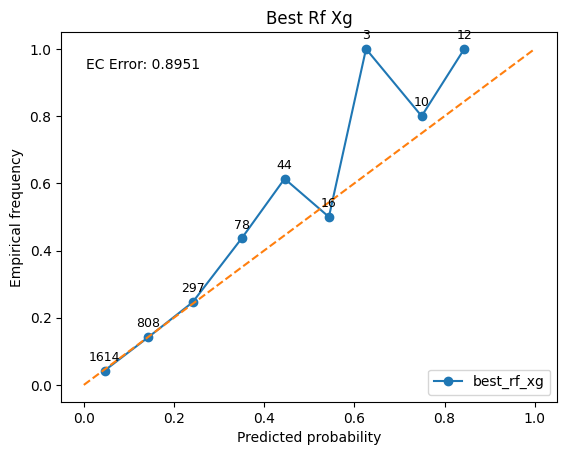

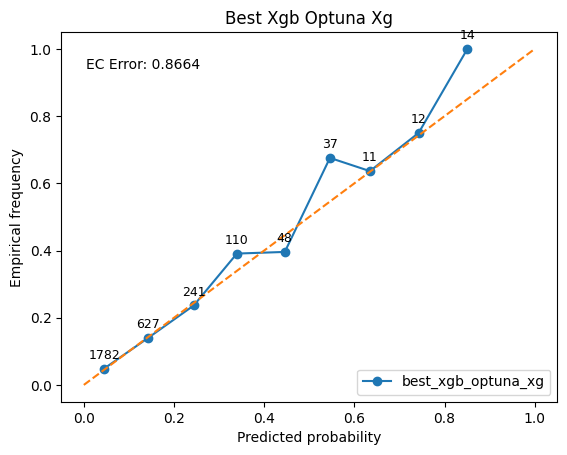

In [64]:
show_calibration_curve(results[['goal', 'best_rf_xg','best_xgb_optuna_xg']])

In [65]:
# İLK ÖNCE BUNU DENE KESİNLİKLE
# - AAAAAAAAAAAAAAA EXP2 DENEYİNİ Bİ DE NEG LOG LOSS İLE YAP. AZ ÖNCE LOGLOSS YAZMAYA ÇALIŞTIM O YÜZDEN OLMADI BELKİ DE.
# BU KONU İÇİN ACİL TXT DOSYASINDAKİ EN SON REPLY A BAK. ÖZETLE DİYO Kİ BRİER SCORE 0.98LİK GOL ŞANSINI ÇOK CEZALANDIRDIĞI İÇİN MODELE RAHAT ALAN BIRAKMAZ. MODEL KUTUPLAŞIR ECE DÜŞER


# AŞAĞIDAKİ İŞLEMLER SIRASINDA TRAIN SCORE A DA BAKILSIN OVERFITTING VAR MI ANLAŞILSIN (GERİ GELDİM ÖNEMLİ Bİ NOKTAYI HATIRLATICAM.)
# (OPTUNA MODELİNDEKİ EĞİTİME DOKUNMADAN ÖNCE OVERFITTING OLMUŞ MU DİYE Bİ BAK. MUHTEMELEN ŞU AN EĞİTİM İYİ AMA TEST SETİNDE BOCALIYO ŞU ANKİ MODELLERİMİZ)
# (OPTUNAYA BAKARKEN EARLY STOPPING MESELESİNİ DE İNCELE. ÖYLE BİŞE DE VARDI. BELKİ O ŞEKİLDE ENGELLEYEBİLİRİZ OVERFITTING VARSA)

# GEMINI DA DİYOR Kİ: Cross-Validation'a Bak: Optuna kullanırken cross_val_score yerine daha stabil bir sonuç almak için StratifiedKFold kullanıyorsun, bu iyi.
# Ancak scoring='neg_brier_score' yerine varsayılan olan log_loss (yani neg_log_loss) ile bir kere dene.
# XGBoost'un kalbi log_loss ile atar, onu değiştirmek modelin dengesini bozabilir.


# BU HÜCREYİ TAMAMEN ESKİSİNDEN KOPYALADIM. VE TEK FARKI NEG_MAE KULLANILMASI. RANDOMIZED XGB, OPTUNA XGB VE BU EXP XGB İÇİN MAE,LOGLOSS,BRİER İÇEREN SCORING İLE EXCEL DOSYASINDA İNCELEME YAP.
# AMACIMIZ MAE YE GÖRE SEÇİLEN BU MODELİN DİĞER METRİKLERDE NEDEN ÇOK KÖTÜ OLDUĞUNU ANLAMAK. EXCELDE MAE YE GÖRE SIRALAYIP MAE BİRİNCİLERİNİN BRİER VE LOGLOSS UNA BAKACAĞIM.

# ESKİDEKİ PERFORMANSI YAKALAYABİLİRSEK VE EĞER BİR SORUN YOKSA PROJEYİ YAVAŞTAN TOPARLAYIP UI YAPIP KAPATACAĞIZ.

# random xgb ile yaptığımız gözlemdeki mae si en yüksek olan modelin ece sine bakcaz ve brier ı en yüksek olan modelin ecesine bakcaz. ulan bu exp xgb modelini mae ye göre seçtik ecesi bayaa iyi çıkıyo lan. neden oluyo bu acaba?

# Initialize the XGBoost classifier
mae_temp_xgb_model = xgb.XGBClassifier(objective='binary:logistic', random_state=42)

# Use RandomizedSearchCV for hyperparameter tuning (more efficient for large parameter grids)
mae_random_search_xgb = RandomizedSearchCV(estimator=mae_temp_xgb_model, param_distributions=param_grid_xgb, n_iter=50,
                                           scoring='neg_mean_absolute_error', cv=5, verbose=2, random_state=42, n_jobs=-1, return_train_score=True)

# Fit the randomized search to the training data
mae_random_search_xgb.fit(X_train, y_train)

# Get the best hyperparameters and best score
print("Best Hyperparameters (XGBoost):", mae_random_search_xgb.best_params_)
print("Best Score (XGBoost):", mae_random_search_xgb.best_score_)

# Train the best XGBoost model
mae_best_xgb_model = mae_random_search_xgb.best_estimator_
mae_best_xgb_pred = mae_best_xgb_model.predict_proba(X_test)[:, 1]

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Hyperparameters (XGBoost): {'subsample': 0.8, 'reg_alpha': 0, 'n_estimators': 50, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best Score (XGBoost): -0.10620390455531455


In [66]:
results['mae_best_xgb_xg'] = mae_best_xgb_pred

In [67]:
metrics = evaluate_model(results, metrics, 'mae_best_xgb_xg')

,statsbomb_xg,log_xg,rf_xg,best_rf_xg,xgb_xg,random_xgb_xg,best_xgb_optuna_xg,mae_best_xgb_xg
metric,,,,,,,,
mae,0.165,0.174,0.179,0.178,0.166,0.173,0.174,0.172
Log_Loss,0.299,0.304,0.382,0.303,0.336,0.299,0.300,0.300
brier,0.087,0.088,0.092,0.089,0.095,0.087,0.087,0.087
ece(x100),1.628,0.809,2.702,0.895,4.206,1.119,0.866,0.655
xg_sum(349),302.778,334.343,351.410,336.752,317.739,335.595,335.722,331.974
xg_ratio,0.868,0.958,1.007,0.965,0.910,0.962,0.962,0.951


In [68]:
pt_mae_xgb = pd.DataFrame(mae_random_search_xgb.cv_results_)
pt_mae_xgb.to_excel('mae_random_search_xgb.xlsx')

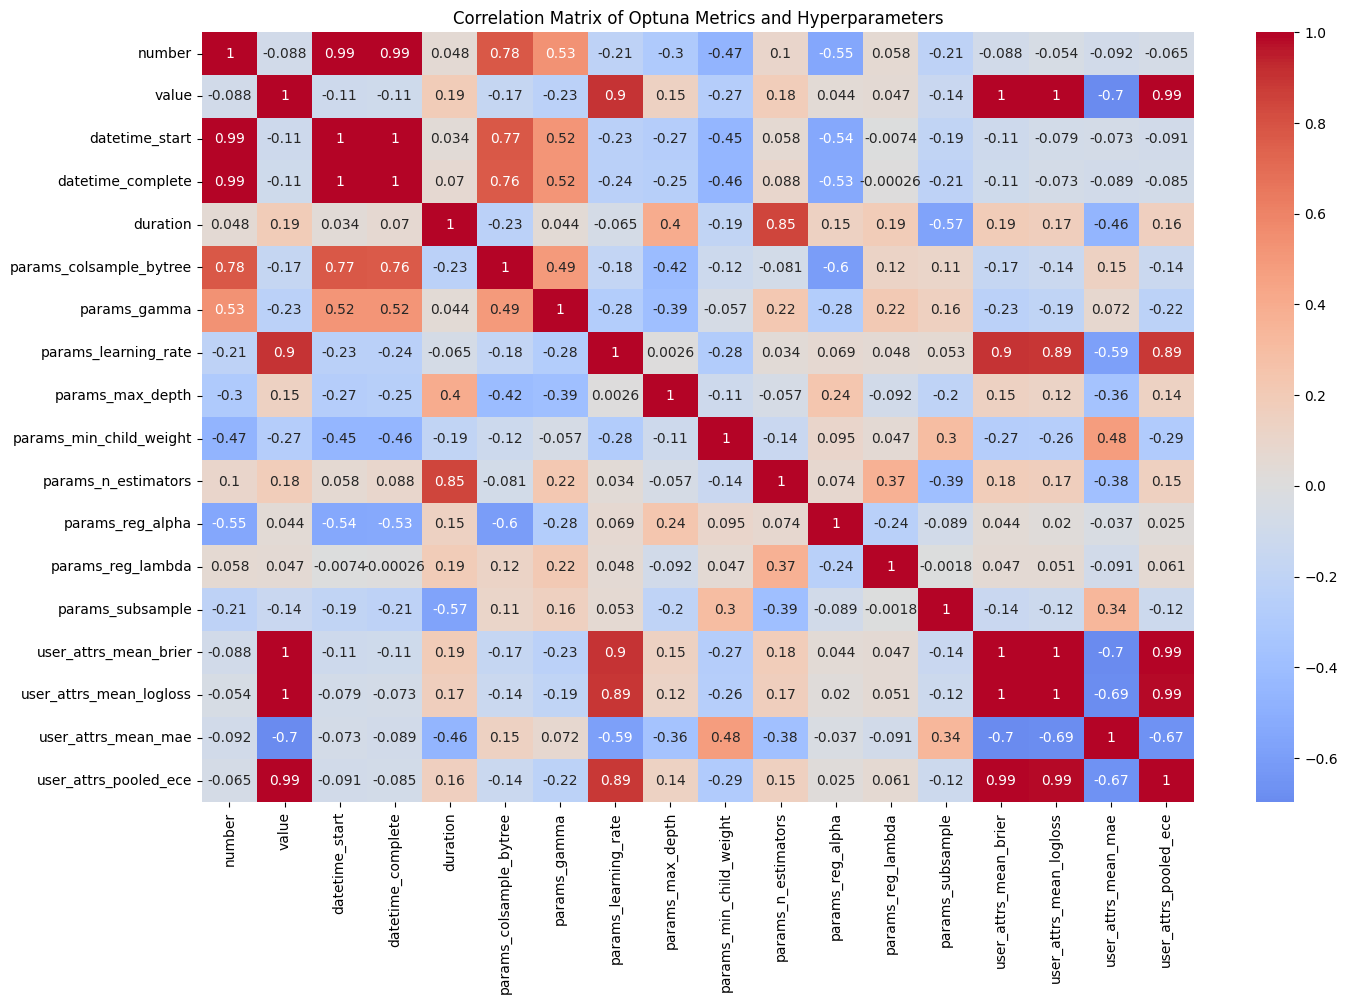

In [69]:
# optuna metrics correlations with other metrics and hyperparameters. create a correlation matrix and show it with heatmap

import matplotlib.pyplot as plt

metrics_corrs = pd.DataFrame(study.trials_dataframe())

# Assuming you have a DataFrame `metrics_corrs` with your metrics and hyperparameters
correlation_matrix = metrics_corrs.drop(['state'], axis=1).corr()

plt.figure(figsize=(16, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Optuna Metrics and Hyperparameters')
plt.show()

In [70]:
# pooled ece corr
correlation_matrix_pooled_ece = metrics_corrs.drop(['state'], axis=1).corr()['user_attrs_pooled_ece']
print("Correlation of pooled ECE with other metrics and hyperparameters:")
print(correlation_matrix_pooled_ece)

Correlation of pooled ECE with other metrics and hyperparameters:
number                    -0.065410
value                      0.991224
datetime_start            -0.090697
datetime_complete         -0.084583
duration                   0.163215
params_colsample_bytree   -0.140045
params_gamma              -0.224217
params_learning_rate       0.887091
params_max_depth           0.137640
params_min_child_weight   -0.286912
params_n_estimators        0.153329
params_reg_alpha           0.025271
params_reg_lambda          0.061138
params_subsample          -0.124482
user_attrs_mean_brier      0.991224
user_attrs_mean_logloss    0.985712
user_attrs_mean_mae       -0.667933
user_attrs_pooled_ece      1.000000
Name: user_attrs_pooled_ece, dtype: float64


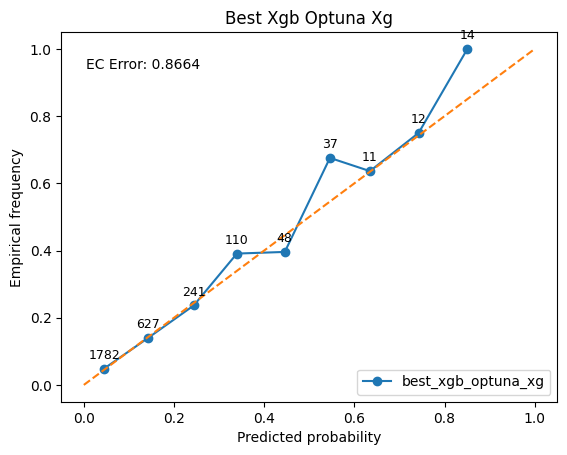

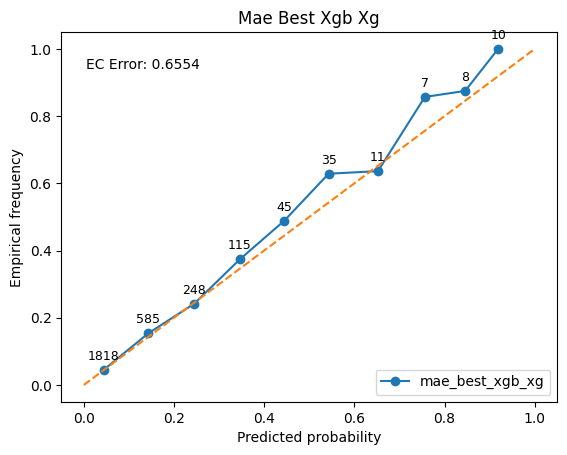

In [71]:
# cal curve for mae_best_xgb_xg
show_calibration_curve(results[['goal', 'best_xgb_optuna_xg', 'mae_best_xgb_xg']])

## LIGHT GBM

FEATURE ENGINEERING DENE.

LIGHTGBM KULLANARAK DENE.

In [72]:
import math

def calculate_angle(x, y):

  g0 = [120, 44]
  p = [x, y]
  g1 = [120, 36]

  v0 = np.array(g0) - np.array(p)
  v1 = np.array(g1) - np.array(p)

  angle = math.atan2(np.linalg.det([v0,v1]),np.dot(v0,v1))
  return(abs(np.degrees(angle)))

def calculate_distance(x, y):
  x_dist = 120-x
  y_dist = 0
  if (y<36):
    y_dist = 36-y
  elif (y>44):
    y_dist = y-44
  return math.sqrt(x_dist**2 + y_dist**2)

In [73]:
X_train.columns

Index(['x', 'y', 'minute', 'shot_aerial_won', 'shot_foot', 'shot_first_time',
       'shot_one_on_one', 'shot_open_goal', 'under_pressure',
       'play_pattern_From Corner', 'play_pattern_From Counter',
       'play_pattern_From Free Kick', 'play_pattern_From Goal Kick',
       'play_pattern_From Keeper', 'play_pattern_From Kick Off',
       'play_pattern_From Throw In', 'play_pattern_Other',
       'play_pattern_Regular Play', 'technique_Backheel',
       'technique_Diving Header', 'technique_Half Volley', 'technique_Lob',
       'technique_Normal', 'technique_Overhead Kick', 'technique_Volley',
       'angle', 'distance', 'num_opponents_around', 'num_blocking_players'],
      dtype='object')

In [74]:
results.columns

Index(['goal', 'statsbomb_xg', 'log_xg', 'rf_xg', 'best_rf_xg', 'xgb_xg',
       'random_xgb_xg', 'best_xgb_optuna_xg', 'mae_best_xgb_xg'],
      dtype='object')

In [75]:
# @title New Shot Prediction
# Örnek kullanım
x = 105
y = 33.5


# ['x', 'y', 'minute',
# 'shot_aerial_won', 'shot_foot', 'shot_first_time', 'shot_one_on_one', 'shot_open_goal', 'under_pressure',

# 'play_pattern_From Corner', 'play_pattern_From Counter', 'play_pattern_From Free Kick', 'play_pattern_From Goal Kick',
# 'play_pattern_From Keeper', 'play_pattern_From Kick Off', 'play_pattern_From Throw In', 'play_pattern_Other', 'play_pattern_Regular Play',

# 'technique_Backheel', 'technique_Diving Header', 'technique_Half Volley', 'technique_Lob', 'technique_Normal', 'technique_Overhead Kick', 'technique_Volley',

# 'angle', 'distance',

# 'num_opponents_around', 'num_blocking_players']]


new_shot_data = [x, y, 8,
                 0, 1, 0, 1, 0, 0,

                 0, 0, 0, 0,
                 0, 0, 0, 0, 1,

                 0, 0, 0, 0, 1, 0, 0,

                 calculate_angle(x,y), calculate_distance(x,y),

                 0, 1]   # Örnek veriler

new_shot_data_df = pd.DataFrame([new_shot_data], columns=X.columns)



# Ölçeklenmiş versiyonları hazırla
new_shot_data_df[continuous_cols] = minmaxscaler.transform(new_shot_data_df[continuous_cols])
new_shot_data_df[discrete_cols] = standardscaler.transform(new_shot_data_df[discrete_cols])

# Model + uygun veri ile tahmin yap, dict içinde tut
new_shot_predictions = {}

new_shot_predictions['log_xg'] = logistic_model.predict_proba(new_shot_data_df)[:, 1].round(2)


new_shot_predictions['rf_xg'] = rf_model.predict_proba(new_shot_data_df)[:, 1].round(2)
new_shot_predictions['best_rf_xg'] = best_rf_model.predict_proba(new_shot_data_df)[:, 1].round(2)


new_shot_predictions['xgb_xg'] = xgb_model.predict_proba(new_shot_data_df)[:, 1].round(2)
new_shot_predictions['random_xgb_xg'] = random_xgb_model.predict_proba(new_shot_data_df)[:, 1].round(2)
new_shot_predictions['best_xgb_optuna_xg'] = best_xgb_model_optuna.predict_proba(new_shot_data_df)[:, 1].round(2)
new_shot_predictions['mae_best_xgb_xg'] = mae_best_xgb_model.predict_proba(new_shot_data_df)[:, 1].round(2)



# show as table
new_shot_predictions_df = pd.DataFrame(new_shot_predictions, index=[0])

# mean of best rf and best xgb
# new_shot_predictions_df['best_mean'] = new_shot_predictions_df[['models']].mean(axis=1)

new_shot_predictions_df

,log_xg,rf_xg,best_rf_xg,xgb_xg,random_xgb_xg,best_xgb_optuna_xg,mae_best_xgb_xg
0,1.0,0.26,0.29,0.07,0.18,0.14,0.29


In [76]:
display(metrics.style.format("{:.3f}"))

,statsbomb_xg,log_xg,rf_xg,best_rf_xg,xgb_xg,random_xgb_xg,best_xgb_optuna_xg,mae_best_xgb_xg
metric,,,,,,,,
mae,0.165,0.174,0.179,0.178,0.166,0.173,0.174,0.172
Log_Loss,0.299,0.304,0.382,0.303,0.336,0.299,0.300,0.300
brier,0.087,0.088,0.092,0.089,0.095,0.087,0.087,0.087
ece(x100),1.628,0.809,2.702,0.895,4.206,1.119,0.866,0.655
xg_sum(349),302.778,334.343,351.410,336.752,317.739,335.595,335.722,331.974
xg_ratio,0.868,0.958,1.007,0.965,0.910,0.962,0.962,0.951


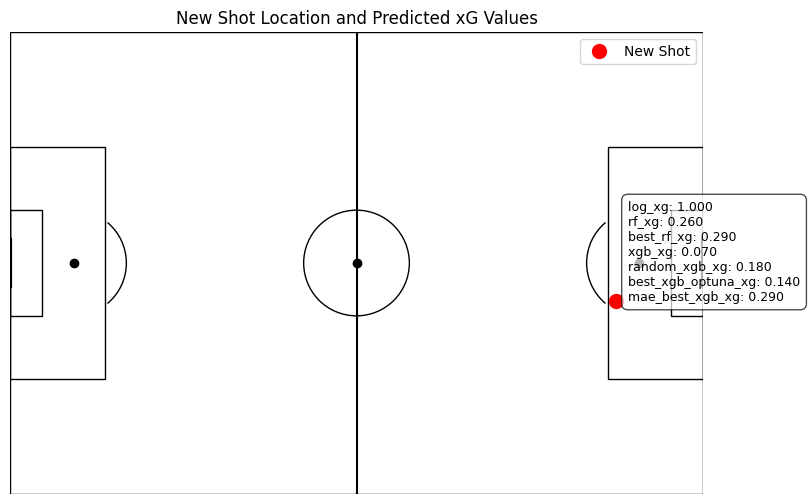

In [77]:
# prompt: show new shot data on the pitch


import matplotlib.patches as patches


def create_full_pitch(figsize=(10, 6)):
    """
    Creates a matplotlib figure and axes representing a full football pitch.

    Returns:
        tuple: A tuple containing the matplotlib figure and axes objects.
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Pitch Dimensions (example for a standard 120x80 meter pitch scaled to 120x80)
    pitch_width = 80  # Width of the pitch
    pitch_length = 120  # Length of the pitch
    line_color = 'black'

    # Pitch outline
    ax.add_patch(patches.Rectangle((0, 0), pitch_length, pitch_width, edgecolor=line_color, facecolor='none'))

    # Halfway line
    ax.add_line(plt.Line2D([pitch_length/2, pitch_length/2], [0, pitch_width], color=line_color))

    # Center Circle
    ax.add_patch(patches.Circle((pitch_length/2, pitch_width/2), 9.15, edgecolor=line_color, facecolor='none'))

    # Center Spot
    ax.plot(pitch_length/2, pitch_width/2, 'o', color=line_color)

    # Left Penalty Area
    ax.add_patch(patches.Rectangle((0, pitch_width/2 - 20.13), 16.5, 40.26, edgecolor=line_color, facecolor='none'))
    # Left Goal Area
    ax.add_patch(patches.Rectangle((0, pitch_width/2 - 9.15), 5.5, 18.3, edgecolor=line_color, facecolor='none'))
    # Left Penalty Spot
    ax.plot(11, pitch_width/2, 'o', color=line_color)
    # Left Arc
    arc = patches.Arc((11, pitch_width/2), 9.15 * 2, 9.15 * 2, angle=0, theta1=310, theta2=50, color=line_color)
    ax.add_patch(arc)
    # Left Goal Line (Goals are typically placed on the goal line)
    ax.add_line(plt.Line2D([0, 0], [pitch_width/2 - 4, pitch_width/2 + 4], color=line_color, linewidth=3)) # Example Goal width

    # Right Penalty Area
    ax.add_patch(patches.Rectangle((pitch_length - 16.5, pitch_width/2 - 20.13), 16.5, 40.26, edgecolor=line_color, facecolor='none'))
    # Right Goal Area
    ax.add_patch(patches.Rectangle((pitch_length - 5.5, pitch_width/2 - 9.15), 5.5, 18.3, edgecolor=line_color, facecolor='none'))
    # Right Penalty Spot
    ax.plot(pitch_length - 11, pitch_width/2, 'o', color=line_color)
    # Right Arc
    arc2 = patches.Arc((pitch_length - 11, pitch_width/2), 9.15 * 2, 9.15 * 2, angle=0, theta1=130, theta2=230, color=line_color)
    ax.add_patch(arc2)
     # Right Goal Line
    ax.add_line(plt.Line2D([pitch_length, pitch_length], [pitch_width/2 - 4, pitch_width/2 + 4], color=line_color, linewidth=3)) # Example Goal width


    # Set limits and aspect ratio
    ax.set_xlim(0, pitch_length)
    ax.set_ylim(0, pitch_width)
    ax.set_aspect('equal', adjustable='box')

    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    return fig, ax

# Create the pitch
fig, ax = create_full_pitch()

# Define the coordinates of the new shot
new_shot_x = new_shot_data[0]
new_shot_y = new_shot_data[1]

# Plot the new shot location
ax.plot(new_shot_x, new_shot_y, 'ro', markersize=10, label='New Shot')

# Add the predicted xG values as text next to the shot
# You can choose which models' predictions to display
def format_prediction_value(xg):
    xg_array = np.asarray(xg).flatten()
    if xg_array.size == 0:
        return "nan"
    return f"{xg_array[0]:.3f}"

predictions_text = '\n'.join([f"{model}: {format_prediction_value(xg)}" for model, xg in new_shot_predictions.items()])

ax.text(new_shot_x + 2, new_shot_y, predictions_text, fontsize=9, bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.7))

# Add a legend (optional)
ax.legend()

# Set title
plt.title('New Shot Location and Predicted xG Values')

plt.show()

In [ ]:
# SHAP analysis for the mae_best_xgb_xg model on the new shot sample
explainer = shap.Explainer(mae_best_xgb_model, X_train)
shap_values_new_shot = explainer(new_shot_data_df)

shap_df = pd.DataFrame({
    'feature': new_shot_data_df.columns,
    'feature_value': new_shot_data_df.iloc[0].values,
    'shap_value': shap_values_new_shot.values[0]
}).sort_values('shap_value', key=abs, ascending=False)

display(shap_df)

print("Predicted xG:", mae_best_xgb_model.predict_proba(new_shot_data_df)[:, 1][0])
print("SHAP expected value:", shap_values_new_shot.base_values[0])

shap.plots.waterfall(shap_values_new_shot[0], max_display=15)

# ----- ***ANN*** -----